In [1]:
import os
import glob
import rioxarray

from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt

import sys

# use absolute path here
project_path = "/mnt/School/PhD/AI221/Project/"
sys.path.insert(0, project_path)

from src.data_extraction.utils.constants import data_path

In [2]:
twi_path = "ph_cop30_tiles/"

In [7]:
files = glob.glob(os.path.join(data_path, twi_path,"*.tif"))

# Load and downsample simultaneously (e.g., take every 10th pixel)
datasets = []
for f in files:
    ds = rioxarray.open_rasterio(f, chunks={'x': 1800, 'y': 1800}).sel(band=1)
    # Downsample for visualization: 1/10th resolution
    ds_small = ds.coarsen(x=10, y=10, boundary="trim").mean()
    datasets.append(ds_small)

# Union (Merge) the rasters
merged = merge_arrays(datasets)

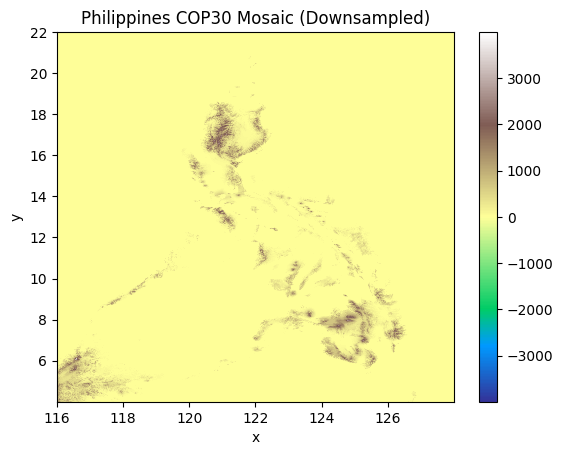

In [9]:
# Validate: The COP30 dataset covers the entire Philippines
merged.plot(cmap='terrain')
plt.title("Philippines COP30 Mosaic (Downsampled)")
plt.show()